In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
rcParams["font.size"] = 12
rcParams["axes.spines.top"] =  False
rcParams["axes.spines.right"] = False

import numpy as np
import matplotlib.pyplot as plt

from neuron_models import LIFModel, run_lif_simulation, launch_lif_app


/Users/charithapalika/Desktop/Lab projects/WORKSHOP/Neuron_models/neuron_models/hh_model.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Run simulation

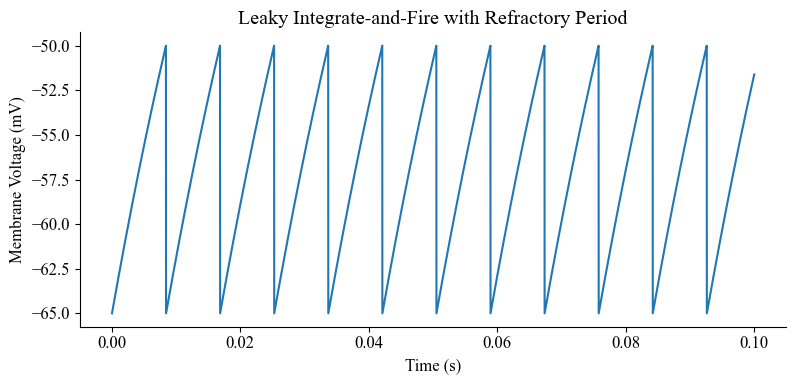

In [3]:
gl = 0.16
Cm = 0.0049
T_ref = 0.002   # 2 ms
dt = 0.00002    # 0.02 ms
T = 0.100       # 100 ms
iterations = int(T / dt)
I_input = 10   # constant current

model = LIFModel(gl=gl, Cm=Cm, El=-65.0, thresh=-50.0, T_ref=T_ref)

V, spike_times = model.solve(
    V0=-65.0,
    dt=dt,
    iterations=iterations,
    I_ext=I_input,
    reset_to_El=True,
    use_refractory=False  
)

time = np.arange(0, iterations + 1) * dt

plt.figure(figsize=(8, 4))
plt.plot(time, V)
plt.xlabel("Time (s)")
plt.ylabel("Membrane Voltage (mV)")
plt.title("Leaky Integrate-and-Fire with Refractory Period")
plt.tight_layout()
plt.show()


## Frequency plotting

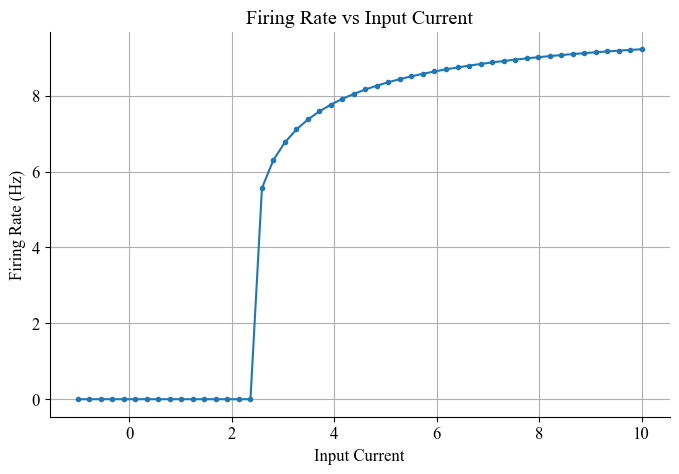

In [4]:
# ---- Parameters ----
I_current = np.linspace(-1, 10, 50)   # different current inputs
gl = 0.16
Cm = 0.0049

dt = 0.00002            # timestep (s)
T = 1 #0.100               # total simulation time (s)
iterations = int(T / dt)
T_ref = 0.05            # refractory period (s)
Ref = True             # whether to use refractory handling inside solver
plot_traces = False     # set True to plot each trace

# ---- Prepare model instance (reuse for each current) ----
model = LIFModel(gl=gl, Cm=Cm, El=-65.0, thresh=-50.0, T_ref=T_ref)

firing_rates = []

for I_in in I_current:
    # run simulation (V returned as length iterations+1, spike_times in seconds)
    V, spike_times = model.solve(
        V0=model.El,
        dt=dt,
        iterations=iterations,
        I_ext=I_in,
        reset_to_El=True,
        use_refractory=Ref,   # <-- uses the new refractory logic
    )

    # optional: plot voltage trace for this input
    if plot_traces:
        time = np.arange(0, iterations + 1) * dt
        plt.figure(figsize=(8, 4))
        plt.plot(time, V, lw=1.2)
        plt.title(f"LIF trace, I = {I_in}")
        plt.xlabel("Time (s)")
        plt.ylabel("Membrane Voltage (mV)")
        plt.show()

    # compute firing rate (Hz)
    if len(spike_times) > 1:
        isi = spike_times[1] - spike_times[0]  # seconds
        if Ref:
            # include refractory period in "cycle length"
            cycle = T_ref + isi
            firing_rate = 1.0 / cycle if cycle > 0 else 0.0
        else:
            firing_rate = 1.0 / isi if isi > 0 else 0.0
    else:
        firing_rate = 0.0

    firing_rates.append(firing_rate)

# ---- Plot Firing Rate vs Input Current ----
plt.figure(figsize=(8, 5))
plt.plot(I_current, firing_rates, marker='.', lw=1.5)
plt.title("Firing Rate vs Input Current")
plt.xlabel("Input Current")
plt.ylabel("Firing Rate (Hz)")
plt.grid(True)
plt.show()


## Launch LIF simulator

In [ ]:
# launch_lif_app()